# 電廠損壞機率模型

* 方法

1. 理論 : Hazard-agnostic approach

   * 傳統分析針對特定災害類型（地震、颱風、洪水）分別建立模型，依賴特定的強度指標（如: 地表加速度、風速、發生時長），分析損壞程度 ( 如: 易損曲線)。
   
   * Hazard-agnostic approach 跳過「何種災害造成損壞」的問題，直接從損壞程度出發，並且非常適合在分析電力系統，因電力系統的損壞除了特定災害外，還有許多機率的意外事件。

   * 以設施損壞程度 $x \in [0,1]$ 作為輸入，不指定特定災害類型。

2. 截斷指數分布

    電力系統損壞事件具有重尾特性，表示低損壞事件頻繁發生、高損壞事件極少發生。Andriotis & Papakonstantinou (2018) 指出，重尾特性的資料適合在對數空間中表示，故其以softmax 函式表達損壞狀態機率。

    此處則採用截斷指數分布作為損壞程度的機率模型：

    $$f(x) = \frac{\alpha e^{-\alpha x}}{1 - e^{-\alpha}}, \quad x \in [0, 1]$$

    * 其中 $\alpha > 0$ 為衰減參數，控制損壞程度集中於低端的程度。$\alpha$ 越大，分布越集中於低損壞；$\alpha$ 越小，高損壞事件的機率相對提高。
    
    * 方程式說明 : 
      * 分子 $\alpha e^{-\alpha x}$ : 指數衰減方程式
      * 分母 $1 - e^{-\alpha}$ : 是對分子 $\alpha e^{-\alpha x}$ 積分 0~1 ，表示 指數衰減 0~1 區間下的總面積
      * 0~1 區間內某點發生次數 / 0~1 總發生次數 = 機率

    * 方程式與論文略微不同，因其係採實際資料點位故採離散分佈



3. α 參數校準

    $\alpha_{base}$ 由 DOE-417 WECC 地區歷史資料反推，以歷史最大值 34 天作為損壞嚴重程度 1.0 。並將所有事件的修復天數除以 34 天進行正規化，得到 $x \in [0,1]$ 的樣本，計算樣本期望值 $\bar{x}$，再由截斷指數分布的期望值解析式反推：

    $$E[x] = \frac{1}{\alpha} - \frac{1}{e^{\alpha} - 1} = \bar{x}$$

    數值求解上式即得 $\alpha_{base}$，使模型的期望損壞程度與歷史資料一致。

4. 情境設計邏輯

歷史資料反映一般狀況下的損壞分布，無法直接代表未來極端事件。目前預計設計三種情境，以壓力測試的方式評估系統在不同嚴重程度下的韌性：

- **一般情境**：以 $\alpha_{base}$ 反映歷史正常狀況
- **壓力情境**：以 $\alpha_{base}/2$ 模擬比歷史更嚴重的損壞分布
- **極端情境**：以 $\alpha_{base}/4$ 模擬假設性極端狀況

壓力與極端情境的倍率設定（1/2、1/4）作為敏感度分析的對象，用以驗證韌性結論對參數設定的穩健性。

---

* 模型架構

  1. 整體流程

      ``` bash
      DOE-417 歷史資料
          ↓
      正規化（÷ 34天）→ x ∈ [0,1]
          ↓
      計算樣本期望值 x̄，反推 α_base
          ↓
      定義三種情境的 alpha
          ↓
      Monte Carlo 抽樣（大量 episodes）
          ↓
      韌性分析
      ```

  2. 第一層：情境抽樣

        每次 Monte Carlo episode 依下列機率抽取情境：(機率可以討論，我自己假設的)

        | 情境 | 抽樣機率 | alpha | 意義 |
        |------|---------|-------|------|
        | 一般 | 80% | $\alpha_{base}$ | 歷史正常狀況 |
        | 壓力 | 15% | $\alpha_{base} / 2$ | 比歷史更嚴重 |
        | 極端 | 5% | $\alpha_{base} / 4$ | 假設性極端狀況 |


  3. 第二層：損壞等級抽樣

        依抽取情境對應的 $\alpha$，從截斷指數分布抽取連續損壞值 $x \in [0,1]$，由於電腦隨機取樣為等權的，為了體現出我們實際的機率分布取樣，須採用 inverse transform sampling：

        $$x = -\frac{1}{\alpha} \ln\left(1 - u \cdot (1 - e^{-\alpha})\right), \quad u \sim \text{Uniform}(0,1)$$

        $u$ : 累積機率的積分

        * 簡單來說 : 這樣做的原因是因為，我們每個 x 值的取樣機率是不一樣的


  4. 第三層：損壞值對應修復天數

        $$\text{修復天數} = x \times 34$$

        以 DOE-417 WECC 地區歷史最長修復時間 34 天作為正規化基準，直接將損壞程度映射至修復天數，避免引入額外的轉換假設。

---

* 參考文獻

- Andriotis, C. P., & Papakonstantinou, K. G. (2018). Extended and generalized fragility functions. *Journal of Engineering Mechanics*, 144(9), 04018087.
- U.S. Department of Energy. DOE-417 Electric Emergency Incident and Disturbance Report.

# 1. 讀取 DOE-417 資料

In [2]:
import pandas as pd
import numpy as np
import os

DATA_DIR = "data"

# 讀入 DOE-417 WECC 清理後資料
df = pd.read_csv(os.path.join(DATA_DIR, "doe_wecc.csv"))

# 計算正規化基準（全域最大值）
global_max = df["duration_minutes"].max()

# 正規化：x ∈ [0, 1]
x = df["duration_minutes"] / global_max

# 樣本期望值
x_bar = x.mean()

print(f"global_max : {global_max:.2f} 分鐘 ({global_max/1440:.4f} 天)")
print(f"樣本數     : {len(x)}")
print(f"x̄          : {x_bar:.6f}")

global_max : 49487.00 分鐘 (34.3660 天)
樣本數     : 763
x̄          : 0.015634


# 解 α_base 數值

令理論期望值等於歷史樣本期望值 $\bar{x}$：

$$\frac{1}{\alpha} - \frac{1}{e^{\alpha} - 1} = \bar{x}$$

* 由 $\bar{x}$ 求 $\alpha$ 無解析解，以 Brent 法數值求根得 $\alpha_{base}$。

* Brent 法需要指定一個包含解的區間 $[a, b]$，確認方式是看區間兩端的函數值是否一正一負：

    - $\alpha$ 很小時，$E[x]$ 接近 0.5，遠大於 $\bar{x}$，所以 $g(a) > 0$
    - $\alpha$ 很大時，$E[x]$ 接近 0，遠小於 $\bar{x}$，所以 $g(b) < 0$

    一正一負代表中間必有一個零點，Brent 法即在此區間內搜尋。

In [ ]:
from scipy.optimize import brentq

# 截斷指數分布期望值解析式
# E[x] = 1/α - 1/(e^α - 1) = x_bar
def truncated_exp_mean(alpha):
    return 1/alpha - 1/(np.exp(alpha) - 1)

# 令 E[x] - x_bar = 0，數值求解 α_base
# a, b : α_base 上下限
alpha_base = brentq(lambda a: truncated_exp_mean(a) - x_bar, a=1e-6, b=100)

print(f"α_base : {alpha_base:.6f}")
print(f"驗證   : E[x] = {truncated_exp_mean(alpha_base):.6f}，x̄ = {x_bar:.6f}")

α_base : 63.961386
驗證   : E[x] = 0.015634，x̄ = 0.015634


# 3. 三種情況下的 α 

In [ ]:
# 三種情境的 alpha
alpha_stress  = alpha_base / 2
alpha_extreme = alpha_base / 4

# 各情境期望修復天數 = E[x] × global_max_days
global_max_days = global_max / 1440

scenarios = {
    "Normal" : alpha_base,
    "Stress" : alpha_stress,
    "Extreme": alpha_extreme,
}

print(f"global_max : {global_max_days:.4f} 天\n")
print(f"{'情境':<10} {'alpha':>10} {'E[x]':>10} {'期望修復天數':>12}")

print("-" * 45)
for name, alpha in scenarios.items():
    # 期望值
    ex   = truncated_exp_mean(alpha)
    days = ex * global_max_days
    print(f"{name:<10} {alpha:>10.4f} {ex:>10.6f} {days:>12.4f}")

global_max : 34.3660 天

情境              alpha       E[x]       期望修復天數
---------------------------------------------
Normal        63.9614   0.015634       0.5373
Stress        31.9807   0.031269       1.0746
Extreme       15.9903   0.062538       2.1492


# 4. 視覺化

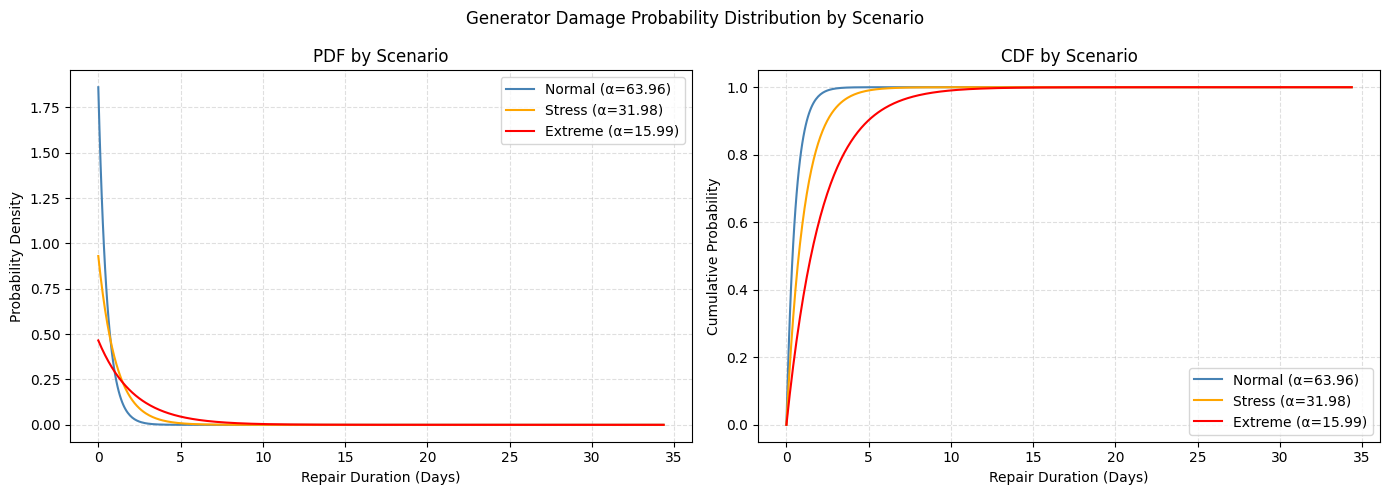

In [9]:
import matplotlib.pyplot as plt

def truncated_exp_pdf(x, alpha):
    return alpha * np.exp(-alpha * x) / (1 - np.exp(-alpha))

def truncated_exp_cdf(days, alpha, global_max_days):
    x = days / global_max_days
    return (1 - np.exp(-alpha * x)) / (1 - np.exp(-alpha))

x_vals      = np.linspace(0, 1, 500)
x_vals_days = x_vals * global_max_days
colors      = {"Normal": "steelblue", "Stress": "orange", "Extreme": "red"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, alpha in scenarios.items():
    pdf      = truncated_exp_pdf(x_vals, alpha)
    pdf_days = pdf / global_max_days
    cdf      = truncated_exp_cdf(x_vals_days, alpha, global_max_days)
    axes[0].plot(x_vals_days, pdf_days, label=f"{name} (α={alpha:.2f})", color=colors[name])
    axes[1].plot(x_vals_days, cdf,      label=f"{name} (α={alpha:.2f})", color=colors[name])

axes[0].set_xlabel("Repair Duration (Days)")
axes[0].set_ylabel("Probability Density")
axes[0].set_title("PDF by Scenario")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.4)

axes[1].set_xlabel("Repair Duration (Days)")
axes[1].set_ylabel("Cumulative Probability")
axes[1].set_title("CDF by Scenario")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.4)

plt.suptitle("Generator Damage Probability Distribution by Scenario")
plt.tight_layout()
plt.show()

# 5. 參數存檔

In [ ]:
import json
import os

params_path = os.path.join(DATA_DIR, "repair_params.json")

# 讀取既有檔案（若已存在）
if os.path.exists(params_path):
    with open(params_path, "r") as f:
        all_params = json.load(f)
else:
    all_params = {}

# 寫入 generator 參數
all_params["generator"] = {
    "global_max_minutes": global_max,
    "alpha_base":         alpha_base,
    "alpha_stress":       alpha_stress,
    "alpha_extreme":      alpha_extreme,
}

# Check 當前 JSON 檔案內資料
with open(params_path, "w") as f:
    json.dump(all_params, f, indent=2)

print(json.dumps(all_params, indent=2))

{
  "grid": {
    "mu": 3.8812424228704416,
    "sigma": 2.308251766693934
  },
  "transformer": {
    "mu": 4.327834748371698,
    "sigma": 2.392484666393898
  },
  "generator": {
    "global_max_minutes": 49487.0,
    "alpha_base": 63.96138626607986,
    "alpha_stress": 31.98069313303993,
    "alpha_extreme": 15.990346566519966
  }
}
